# 🧠 Sprint 1 Planning & Neural Network Architecture

**BinX Tech • AI & Machine Learning Internship — Week 6, Day 1**  
**Phase 3 — Sprint 1: Deep Learning & Applied Project**  
**Project:** Fraud Detection Model  
**Dataset:** `creditcard.csv`

> **Day 1 focus:** Sprint 1 planning, dataset finalization, data-quality checks, EDA, a leakage-safe baseline model, and the foundations of neural-network architecture.

This notebook follows the Week 6 Day 1 curriculum: establish a baseline first, understand the neuron as a weighted sum plus bias and activation, and connect input/hidden/output layers to the project. The training baseline is intentionally kept simple so that future neural-network models have a meaningful benchmark.

## 🎯 Learning Objectives & Evidence Map

| Objective | Evidence in this notebook |
|---|---|
| Complete Sprint 1 planning | Sprint goal, backlog, acceptance criteria |
| Finalize and inspect the project dataset | Dataset profile, quality and sanity checks |
| Establish a baseline model | Leakage-safe Logistic Regression pipeline |
| Record a baseline score | ROC-AUC, PR-AUC, precision, recall, F1, confusion matrix |
| Explain neural-network architecture | Neuron, weights, bias, input/hidden/output layers |
| Apply professional workflow | Reproducibility, leakage checks, visual evidence, clear conclusions |

## 🗓️ Sprint 1 Planning

### Sprint Goal
Build a trustworthy first benchmark for the Fraud Detection project and establish the neural-network foundation needed for the next training days.

### Backlog
1. Finalize the dataset used for Sprint 1.
2. Run data-quality and sanity checks.
3. Check for possible target leakage before modeling.
4. Perform a focused EDA on class balance, transaction amount, time, and feature relationships.
5. Split the data with stratification and keep preprocessing inside a pipeline.
6. Train and evaluate a Logistic Regression baseline.
7. Record the baseline metrics that later neural-network experiments must beat.
8. Explain the neural-network architecture that will be used in the next stages.

### Acceptance Criteria
- Notebook runs from top to bottom without errors.
- No preprocessing statistics are learned from the test set.
- Target leakage is explicitly checked.
- Baseline metrics are calculated from the held-out test set.
- Results are reproducible with a fixed random seed.
- Baseline results are documented before moving to a neural network.

In [1]:
# 🔧 Imports & Reproducibility
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("creditcard.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/creditcard.csv")

print(f"Using dataset: {DATA_PATH}")
print(f"Random seed: {RANDOM_STATE}")

Using dataset: creditcard.csv
Random seed: 42


In [2]:
# 📂 Load the Dataset
raw_df = pd.read_csv(DATA_PATH)

df = raw_df.copy()

print(f"Raw dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst five rows:")
display(df.head())

Raw dataset shape: 284,807 rows × 31 columns

First five rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 🔍 Dataset Profile

The target column is `Class`, where the fraud class is represented by `1` and the non-fraud class by `0`. The dataset contains transaction-level numerical features, including `Time`, anonymized `V1`–`V28`, and `Amount`.

In [3]:
# 🔎 Data Types, Missing Values & Basic Statistics
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(4),
    "unique_values": df.nunique(),
})

display(profile)

print(f"Total missing values: {int(df.isna().sum().sum()):,}")
print(f"Total exact duplicate rows: {int(df.duplicated().sum()):,}")

,dtype,missing_values,missing_%,unique_values
Time,float64,0,0.0,124592
V1,float64,0,0.0,275653
V2,float64,0,0.0,275655
V3,float64,0,0.0,275657
V4,float64,0,0.0,275654
V5,float64,0,0.0,275657
V6,float64,0,0.0,275652
V7,float64,0,0.0,275651
V8,float64,0,0.0,275643
V9,float64,0,0.0,275656


Total missing values: 0


Total exact duplicate rows: 1,081


In [4]:
# 🧪 Target Sanity Check
print("Target value counts:")
display(df["Class"].value_counts().rename_axis("Class").to_frame("Count"))

class_summary = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .to_frame()
)
display(class_summary.round(4))

assert set(df["Class"].dropna().unique()).issubset({0, 1}), "Unexpected target values found."
assert df["Class"].isna().sum() == 0, "Target contains missing values."

Target value counts:


,Count
Class,
0,284315
1,492


,Percentage
Class,
0,99.8273
1,0.1727


## 🚨 Data-Quality Decision: Exact Duplicates

The raw file contains exact duplicate rows. Because duplicate observations can cause the same transaction to appear in both training and test data, keeping them during a baseline split could make evaluation less trustworthy. For this Sprint 1 benchmark, exact duplicates are removed **before** the train/test split.

This is deliberately documented rather than silently dropping rows. The original raw dataset remains untouched in `raw_df`, while `df` becomes the modeling dataset.

In [5]:
# 🧹 Remove Exact Duplicates Before Splitting
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)

print(f"Rows before duplicate removal: {before:,}")
print(f"Exact duplicate rows removed: {removed:,}")
print(f"Rows after duplicate removal: {len(df):,}")
print(f"Remaining duplicate rows: {int(df.duplicated().sum()):,}")

Rows before duplicate removal: 284,807
Exact duplicate rows removed: 1,081
Rows after duplicate removal: 283,726


Remaining duplicate rows: 0


## 📊 EDA — Class Imbalance

Fraud detection is an imbalanced classification problem. Accuracy alone can therefore be misleading: a model could achieve very high accuracy while missing most fraudulent transactions. For this reason, the baseline will report **PR-AUC (Average Precision)**, recall, precision, F1, and ROC-AUC rather than relying on accuracy alone.

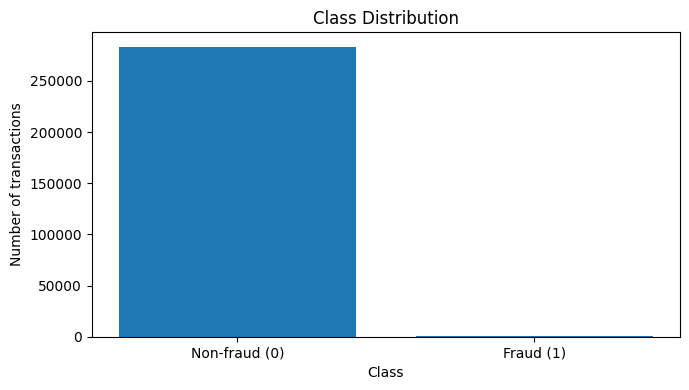

Fraud prevalence after duplicate removal: 0.1667%


In [6]:
# 📈 Class Distribution
class_counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of transactions")
plt.xlabel("Class")
plt.tight_layout()
plt.show()

print(f"Fraud prevalence after duplicate removal: {df['Class'].mean() * 100:.4f}%")

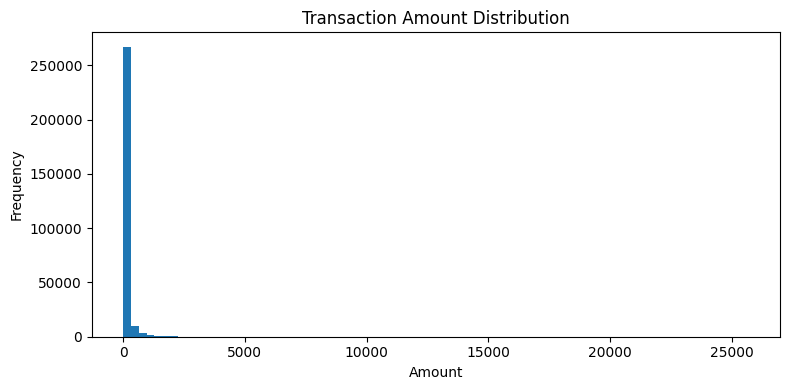

        count  median    mean       max
Class                                  
0      283253   22.00   88.41  25691.16
1         473    9.82  123.87   2125.87


In [7]:
# 💳 Transaction Amount Distribution
plt.figure(figsize=(8, 4))
plt.hist(df["Amount"], bins=80)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df.groupby("Class")["Amount"].agg(["count", "median", "mean", "max"]).round(2))

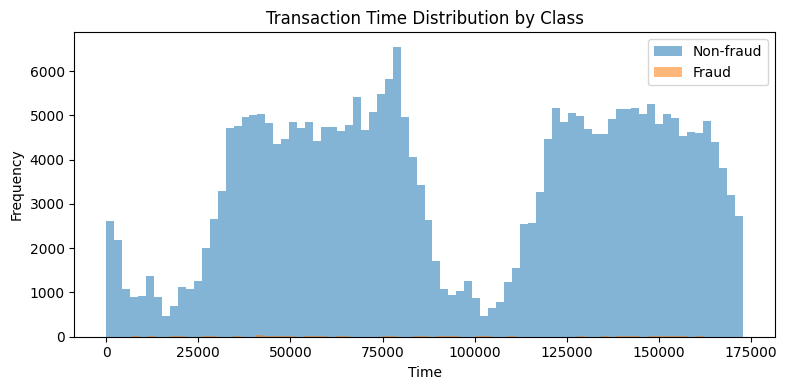

In [8]:
# ⏱️ Transaction Time Distribution by Class
plt.figure(figsize=(8, 4))
plt.hist(df.loc[df["Class"] == 0, "Time"], bins=80, alpha=0.55, label="Non-fraud")
plt.hist(df.loc[df["Class"] == 1, "Time"], bins=80, alpha=0.55, label="Fraud")
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 🧩 Feature Sanity & Leakage Check

A direct leakage check should confirm that the target is not present among the predictors. More importantly, preprocessing must not learn information from the held-out test set. The baseline therefore uses a `Pipeline` containing `StandardScaler` and Logistic Regression, and the pipeline is fitted only on the training split.

The target `Class` is excluded explicitly from `X`. The split is stratified so the rare fraud class is represented in both training and test sets.

In [9]:
# 🚨 Target Leakage Check
TARGET = "Class"
feature_columns = [c for c in df.columns if c != TARGET]

assert TARGET not in feature_columns
assert TARGET not in df.drop(columns=feature_columns).columns.difference([TARGET])

print(f"Number of predictor features: {len(feature_columns)}")
print(f"Target column excluded from predictors: {TARGET not in feature_columns}")
print("Predictors:", feature_columns)

Number of predictor features: 30
Target column excluded from predictors: True
Predictors: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [10]:
# ✂️ Stratified Train/Test Split
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Training fraud rate: {y_train.mean() * 100:.4f}%")
print(f"Test fraud rate:     {y_test.mean() * 100:.4f}%")

Training set: 226,980 rows
Test set:     56,746 rows
Training fraud rate: 0.1665%
Test fraud rate:     0.1674%


## 🤖 Baseline Model — Logistic Regression

The Week 6 material asks Sprint 1 to establish a simple baseline whose score later models must beat. Logistic Regression is appropriate as a transparent first benchmark for this binary classification task.

Because the classes are highly imbalanced, the baseline uses `class_weight="balanced"`. Standardization is placed inside the same pipeline as the model so the scaling parameters are learned only from the training data. This keeps the evaluation leakage-safe.

In [11]:
# 🏗️ Build the Leakage-Safe Baseline Pipeline
baseline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

baseline.fit(X_train, y_train)

print("Baseline model fitted successfully.")

Baseline model fitted successfully.


In [12]:
# 📏 Evaluate the Baseline on the Held-Out Test Set
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "ROC-AUC": roc_auc_score(y_test, baseline_proba),
    "PR-AUC (Average Precision)": average_precision_score(y_test, baseline_proba),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred),
}

baseline_metrics_df = pd.DataFrame(
    {"Metric": list(baseline_metrics.keys()), "Score": list(baseline_metrics.values())}
)

display(baseline_metrics_df.style.format({"Score": "{:.4f}"}))

print("\nConfusion matrix [rows=true, columns=predicted]:")
print(confusion_matrix(y_test, baseline_pred))

print("\nClassification report:")
print(classification_report(y_test, baseline_pred, digits=4))

,Metric,Score
0,ROC-AUC,0.9657
1,PR-AUC (Average Precision),0.6719
2,Precision,0.0564
3,Recall,0.8737
4,F1,0.1059



Confusion matrix [rows=true, columns=predicted]:
[[55262  1389]
 [   12    83]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9755    0.9875     56651
           1     0.0564    0.8737    0.1059        95

    accuracy                         0.9753     56746
   macro avg     0.5281    0.9246    0.5467     56746
weighted avg     0.9982    0.9753    0.9860     56746



In [13]:
# 📉 Baseline Score Evidence
cm = confusion_matrix(y_test, baseline_pred)

tn, fp, fn, tp = cm.ravel()

print(f"True negatives : {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives : {tp:,}")
print(f"PR-AUC baseline: {baseline_metrics['PR-AUC (Average Precision)']:.4f}")
print(f"Recall baseline: {baseline_metrics['Recall']:.4f}")
print(f"F1 baseline: {baseline_metrics['F1']:.4f}")

True negatives : 55,262
False positives: 1,389
False negatives: 12
True positives : 83
PR-AUC baseline: 0.6719
Recall baseline: 0.8737
F1 baseline: 0.1059


## 🧠 Neural Network Architecture — Day 1 Foundations

### The Neuron

A neuron takes input features, multiplies them by learned weights, adds a bias, and applies an activation function:

**output = activation(dot(inputs, weights) + bias)**

This is the same weighted-sum idea used earlier in the internship, now repeated across many connected neurons.

### Layers

- **Input layer:** receives the raw features.
- **Hidden layer(s):** learn intermediate representations. Multiple hidden layers are what make the network *deep*.
- **Output layer:** produces the final prediction, with its shape and activation determined by the task.

### Parameters

Weights and biases are the learned parameters. Training starts from initial values and adjusts them so predictions become more accurate. The detailed mechanism for how those parameters are updated is covered on Days 2–3.

In [14]:
# 🧮 One-Neuron Conceptual Calculation
# This is a tiny numerical illustration of the Week 6 neuron equation.
inputs = np.array([0.5, -1.0, 2.0])
weights = np.array([0.8, 0.2, -0.4])
bias = 0.1

z = np.dot(inputs, weights) + bias
relu_output = max(0, z)

print(f"Weighted sum + bias (z): {z:.4f}")
print(f"ReLU output: {relu_output:.4f}")

Weighted sum + bias (z): -0.5000
ReLU output: 0.0000


## 🧱 Project Architecture Direction

For the fraud-detection project, the eventual neural network will use the available transaction features as inputs and produce a binary fraud probability at the output. The exact hidden-layer width, regularization, activation, and training configuration will be tested rather than assumed to be optimal.

The important Day 1 principle is that the neural network must earn its place by improving on the baseline. The recorded baseline below is therefore the benchmark for future experiments.

In [15]:
# 🏁 Sprint 1 Baseline Benchmark
baseline_benchmark = pd.DataFrame({
    "Baseline": ["Logistic Regression (class-weighted)"],
    "ROC-AUC": [baseline_metrics["ROC-AUC"]],
    "PR-AUC": [baseline_metrics["PR-AUC (Average Precision)"]],
    "Precision": [baseline_metrics["Precision"]],
    "Recall": [baseline_metrics["Recall"]],
    "F1": [baseline_metrics["F1"]],
})

display(baseline_benchmark.style.format({
    "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}"
}))

print("Any later neural-network model should be evaluated against this same held-out test benchmark.")

,Baseline,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression (class-weighted),0.9657,0.6719,0.0564,0.8737,0.1059


Any later neural-network model should be evaluated against this same held-out test benchmark.


## 🖥️ Hands-On Lab: Sprint 1 Kickoff & Baseline

This section follows the Day 1 Hands-On Lab as a separate, complete workflow:

1. **Sprint planning:** goal and initial backlog were defined above.
2. **Dataset + EDA:** the dataset was finalized after quality checks and exact-duplicate handling, followed by class, amount, and time exploration.
3. **Baseline model:** a simple Logistic Regression model was trained and evaluated.
4. **Feature branch / pull request:** the notebook is prepared as the Sprint 1 baseline artifact; the actual Git commit and pull request happen in the repository workflow outside this notebook.
5. **Baseline score:** the benchmark is recorded explicitly below so every later model has a target to beat.

In [16]:
# 📌 Hands-On Lab — Baseline Score to Beat
print("BASELINE SCORE TO BEAT")
print(f"ROC-AUC : {baseline_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC  : {baseline_metrics['PR-AUC (Average Precision)']:.4f}")
print(f"F1      : {baseline_metrics['F1']:.4f}")
print(f"Recall  : {baseline_metrics['Recall']:.4f}")

BASELINE SCORE TO BEAT
ROC-AUC : 0.9657
PR-AUC  : 0.6719
F1      : 0.1059
Recall  : 0.8737


## 💭 Student Reflection

The biggest practical takeaway from Day 1 is that the neural network should not be treated as an automatic upgrade over a simpler model. The baseline gives the project a concrete reference point, while the quality checks and leakage-safe pipeline make that reference point more trustworthy.

The class distribution also makes the problem different from a normal balanced classification exercise. A model can look strong on accuracy while still being poor at identifying fraud, so I will pay particular attention to PR-AUC, recall, precision, and F1 when comparing future models.

I also found the neuron easier to understand when connecting it to the earlier dot-product concept: a neural network is essentially that weighted-sum operation repeated across layers, with activation functions allowing the network to learn non-linear patterns.

## 🚀 Beyond the Requirement

- Kept the raw dataset separate from the modeling dataframe so data-quality decisions are traceable.
- Quantified exact duplicates instead of silently removing them.
- Used stratified splitting because fraud is rare.
- Put scaling inside the modeling pipeline to prevent train/test preprocessing leakage.
- Reported PR-AUC in addition to ROC-AUC because the positive class is highly imbalanced.
- Recorded the confusion matrix so the trade-off between missed fraud and false alarms is visible.
- Added reproducibility controls with a fixed random seed.
- Defined a concrete baseline benchmark before introducing the neural network.

## ✅ Day 1 Completion Checklist

- [x] Sprint 1 goal and backlog established
- [x] Dataset loaded and profiled
- [x] Data-quality checks completed
- [x] Exact duplicates investigated and handled
- [x] Target sanity check completed
- [x] Leakage check completed
- [x] Focused EDA completed
- [x] Stratified train/test split completed
- [x] Baseline Logistic Regression trained
- [x] Actual test metrics recorded
- [x] Baseline benchmark documented
- [x] Neural-network architecture foundations explained
- [x] Hands-On Lab completed as a separate section

## 📚 Week 6 Source Alignment

This notebook is aligned with the provided BinX Tech Week 6 Day 1 material: Sprint 1 planning and baseline-first methodology, the neuron as weighted sum + bias + activation, input/hidden/output layers, and the requirement to establish a baseline before later neural-network work. fileciteturn0file0L57-L73 fileciteturn0file0L79-L100